In [11]:
!pip install -U google-genai

In [13]:
# CELL 0: ENVIRONMENT SETUP & GOOGLE GEMINI API AUTHENTICATION
# Run this cell first. Installs the official Google GenAI SDK and configures auth.

import os
import time
import math
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Modern Google GenAI SDK
from google import genai
from google.genai import types

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 10


# Secure Gemini API Key Ingestion

# In Google Colab, you can store your key in the Secrets Manager (🔑 icon)
# as 'GEMINI_API_KEY', or enter it securely below when prompted.
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass.getpass("🔑 Enter your Google Gemini API Key: ")
    os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

# Initialize the Gemini Client
client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Google Gemini Client initialized successfully!")

✅ Google Gemini Client initialized successfully!


### SECTION 1: FROM N-GRAMS TO TRANSFORMERS & TOKENISATION MECHANICS

THE ARCHITECTURAL EVOLUTION:

1. N-GRAMS (Statistical Probability):
   P(w_n | w_{n-1}, ..., w_1) ≈ P(w_n | w_{n-1}, ..., w_{n-N+1})
   - Limited to a fixed window of N-1 tokens. Suffers from catastrophic combinatorial explosion.

2. RECURRENT NEURAL NETWORKS (RNNs / LSTMs):
   Processes sequences step-by-step: h_t = f(W * h_{t-1} + U * x_t)
   - Bottleneck: Cannot parallelize training over GPUs; suffers from vanishing gradients over long sequences.

3. TRANSFORMERS (Vaswani et al., 2017):
   Eliminated recurrence completely in favor of SELF-ATTENTION.
   - Computes all pairwise token relationships in parallel across entire documents on GPU clusters.

--------------------------------------------------------------------------------
###TOKENS & SUBWORD TOKENISATION:
--------------------------------------------------------------------------------
LLMs do NOT read characters or full dictionary words. They process SUBWORD TOKENS
generated via algorithms like Byte-Pair Encoding (BPE) or SentencePiece.

WHY CAN'T LLMS EASILY COUNT THE 'r's IN 'strawberry'?
- To humans: 's-t-r-a-w-b-e-r-r-y' (10 individual letters).
- To an LLM Tokenizer: 'strawberry' is split into 2 or 3 integer token IDs (e.g. ['str', 'aw', 'berry']).
- The model never sees the isolated character 'r'; it only sees the vector representation of 'berry'.
- Unless prompted to break words down into individual character tokens, the model calculates
  probabilities over subword tokens, leading to miscounts.

RULE OF THUMB (ENGLISH TEXT):
• 1 Token ≈ 0.75 Words
• 100 Tokens ≈ 75 Words
• 1,000 Words ≈ 1,333 Tokens

In [14]:
# Visualizing Subword Token Splitting Mechanics
import tiktoken

tokenizer = tiktoken.get_encoding("cl100k_base") # Standard BPE tokenizer architecture

def inspect_tokenisation(text_sample: str):
    token_ids = tokenizer.encode(text_sample)
    token_strings = [tokenizer.decode([t_id]) for t_id in token_ids]

    print(f"Input Text: '{text_sample}'")
    print(f"Total Characters: {len(text_sample)} | Total Words: {len(text_sample.split())} | Total Tokens: {len(token_ids)}")
    print("Tokenized Chunks:")
    for idx, (t_id, t_str) in enumerate(zip(token_ids, token_strings)):
        print(f"  [Chunk {idx+1}]: Token ID {t_id:6d} -> '{t_str}'")
    print("-" * 60)

print("=== TOKENISATION INSPECTION EXAMPLES ===\n")
inspect_tokenisation("strawberry")
inspect_tokenisation("Unbelievable, anti-constitutional transformations occurred in 2026.")
inspect_tokenisation("def calculate_fibonacci(n: int) -> int:")

=== TOKENISATION INSPECTION EXAMPLES ===

Input Text: 'strawberry'
Total Characters: 10 | Total Words: 1 | Total Tokens: 3
Tokenized Chunks:
  [Chunk 1]: Token ID    496 -> 'str'
  [Chunk 2]: Token ID    675 -> 'aw'
  [Chunk 3]: Token ID  15717 -> 'berry'
------------------------------------------------------------
Input Text: 'Unbelievable, anti-constitutional transformations occurred in 2026.'
Total Characters: 67 | Total Words: 6 | Total Tokens: 14
Tokenized Chunks:
  [Chunk 1]: Token ID   1844 -> 'Un'
  [Chunk 2]: Token ID  32898 -> 'belie'
  [Chunk 3]: Token ID  24694 -> 'vable'
  [Chunk 4]: Token ID     11 -> ','
  [Chunk 5]: Token ID   7294 -> ' anti'
  [Chunk 6]: Token ID     12 -> '-'
  [Chunk 7]: Token ID  49674 -> 'constitutional'
  [Chunk 8]: Token ID  54070 -> ' transformations'
  [Chunk 9]: Token ID  10222 -> ' occurred'
  [Chunk 10]: Token ID    304 -> ' in'
  [Chunk 11]: Token ID    220 -> ' '
  [Chunk 12]: Token ID   2366 -> '202'
  [Chunk 13]: Token ID     21 -> '6'
 

### SECTION 2: TRANSFORMER ARCHITECTURE & SELF-ATTENTION (Q, K, V)

TRANSFORMER VARIANTS:
1. ENCODER-ONLY (e.g., BERT):
   - Bi-directional context. Ideal for classification, NER, and search embeddings.
2. ENCODER-DECODER (e.g., T5, Original Transformer):
   - Sequence-to-sequence translation and summarization.
3. DECODER-ONLY (e.g., GPT, Gemini, Llama, Claude):
   - Autoregressive next-token prediction. Powers modern generative conversational models.

--------------------------------------------------------------------------------
###THE SELF-ATTENTION INTUITION: QUERY (Q), KEY (K), VALUE (V)
--------------------------------------------------------------------------------
Analogous to a Retrieval / Search Engine:
• QUERY (Q): What a given token is looking for ("Who is the subject?").
• KEY (K): What a given token contains ("I am a singular noun").
• VALUE (V): The actual contextual meaning/information payload to transfer.

THE MATHEMATICAL ATTENTION FORMULA:  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;┌&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;┐  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Q * Kᵀ&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│  
Attention(Q,K,V) = softmax&nbsp;│ ─────────── │ * V  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;√d_k&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;└&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;┘ `
- Q * Kᵀ: Computes dot-product similarity between every token pair (Attention Matrix).
- √d_k: Scaling factor preventing gradient saturation for large dimensions.
- Softmax: Converts similarity scores into a probability distribution (weights sum to 1.0).
- Multiply by V: Computes weighted combination of value vectors.

MULTI-HEAD ATTENTION:
Runs the attention mechanism h times in parallel with different linear projections,
allowing the model to jointly attend to syntactic, semantic, and positional relationships.

POSITIONAL ENCODING:
Because self-attention is permutation-invariant (order-agnostic), positional vectors
(sine/cosine functions or RoPE - Rotary Position Embeddings) are added to input embeddings
so the model distinguishes 'Dog bites man' from 'Man bites dog'.



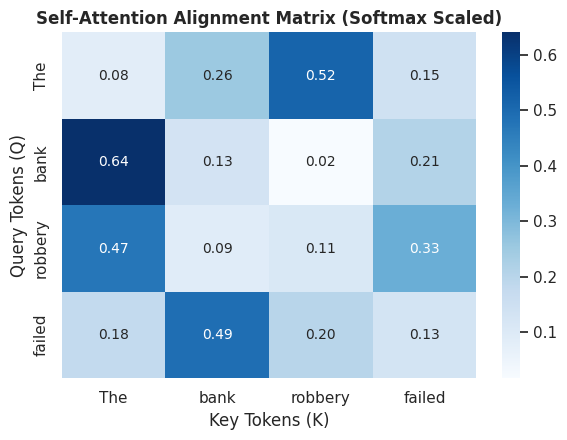

In [15]:
# Numerical Demonstration of Scaled Dot-Product Attention in Pure NumPy
np.random.seed(42)
seq_len = 4
d_k = 8 # Dimension of query/key vectors

# Simulated token representations: ["The", "bank", "robbery", "failed"]
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

# 1. Compute Raw Attention Scores
scores = np.dot(Q, K.T) / np.sqrt(d_k)

# 2. Apply Softmax along rows
attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)

# 3. Compute Contextual Output
context_output = np.dot(attention_weights, V)

tokens = ["The", "bank", "robbery", "failed"]
plt.figure(figsize=(6, 4.5))
sns.heatmap(attention_weights, xticklabels=tokens, yticklabels=tokens, annot=True, fmt=".2f", cmap="Blues")
plt.title("Self-Attention Alignment Matrix (Softmax Scaled)", fontweight="bold")
plt.xlabel("Key Tokens (K)")
plt.ylabel("Query Tokens (Q)")
plt.tight_layout()
plt.show()

### SECTION 3: THE 3-STAGE TRAINING PIPELINE (PRE-TRAINING -> SFT -> RLHF)

HOW A BASE MODEL BECOMES AN ASSISTANT:

STAGE 1: SELF-SUPERVISED PRE-TRAINING (Raw Foundation Model)
- Objective: Predict next token across trillions of tokens from Common Crawl, books, code, arXiv.
- Result: Learns syntax, world knowledge, and reasoning patterns.
- Limitation: Uncontrollable text completer (Prompt: "Write a poem on AI" -> Response: "Write a poem on space...").

STAGE 2: SUPERVISED FINE-TUNING (SFT / Instruction Tuning)
- Objective: Fine-tune base weights on curated (Prompt, Ideal Response) demonstrations.
- Result: Model learns the conversational assistant role (QA, summarization, coding).

STAGE 3: REINFORCEMENT LEARNING FROM HUMAN FEEDBACK (RLHF / DPO)
- Objective: Align model behavior with human values: Helpful, Honest, Harmless (3 H's).
- Mechanism:
  * Humans rank model response pairs (A > B).
  * Train a Reward Model or apply Direct Preference Optimization (DPO) to maximize reward
    while penalizing hallucinations, toxic language, and harmful instructions.

### SECTION 4: INFERENCE HYPERPARAMETERS MATH (TEMPERATURE, TOP-P, TOP-K)

MATHEMATICAL SAMPLING PARAMETERS:

1. TEMPERATURE (T):
   Scales logit scores z_i before applying softmax:
   `P(w_i) = e^(z_i / T) / Σ e^(z_j / T)`

   • T -> 0.0 (Greedy Decoding / Argmax):
     Collapses probability distribution into a delta spike on the single highest-probability token.
     Completely deterministic, repeatable. Ideal for Math, SQL, Code, Extraction.
   • T = 0.7 (Standard Balanced):
     Smooths probabilities slightly, introducing natural diversity while preserving coherence.
   • T > 1.2 (High Entropy / Creative):
     Flattens the distribution, giving low-probability tokens a high chance of selection.
     Highly creative, but prone to incoherence and hallucinations.

2. TOP-K SAMPLING:
   Restricts the candidate pool to only the K highest-probability tokens, zeroing out the rest.

3. TOP-P (NUCLEUS SAMPLING):
   Dynamically selects the smallest set of tokens whose cumulative probability mass exceeds p (e.g., p = 0.90).
   - Adapts candidate pool size dynamically: narrows when model is confident, widens when uncertain.


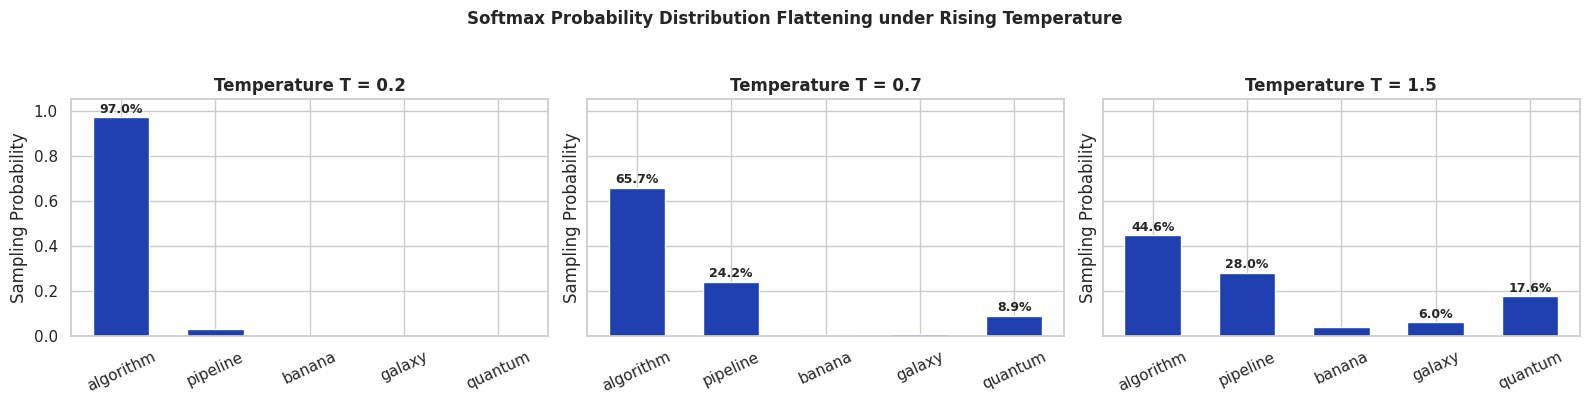

In [17]:
# Visualizing the Mathematical Impact of Temperature on Softmax Logits
candidate_words = ["algorithm", "pipeline", "banana", "galaxy", "quantum"]
raw_logits = np.array([4.2, 3.5, 0.5, 1.2, 2.8])

temperatures = [0.2, 0.7, 1.5]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)

for ax, t in zip(axes, temperatures):
    scaled_exp = np.exp(raw_logits / t)
    probs = scaled_exp / np.sum(scaled_exp)

    bars = ax.bar(candidate_words, probs, color="#1e40af", width=0.6)
    ax.set_title(f"Temperature T = {t}", fontweight="bold")
    ax.set_ylabel("Sampling Probability")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=25)

    for bar in bars:
        h = bar.get_height()
        if h > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f"{h*100:.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Softmax Probability Distribution Flattening under Rising Temperature", fontsize=12, y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()

### SECTION 5: LIVE DEMO 1 — TEMPERATURE DIVERGENCE EXPERIMENT (GEMINI API)

In [18]:
# We run the exact same creative prompt through Gemini across 3 temperatures:
# T = 0.0 (Deterministic) vs T = 0.7 (Balanced) vs T = 1.5 (High Entropy)

import pandas as pd
from google.genai import types

prompt_test = "Write a 2-sentence marketing slogan for an AI-powered coffee maker."
temp_values = [0.0, 0.7, 1.5]
divergence_results = []

print(f"Executing Gemini API Prompt: '{prompt_test}'\n")

for temp in temp_values:
    # Configure generation parameters via types.GenerateContentConfig
    config = types.GenerateContentConfig(
        temperature=temp,
        max_output_tokens=100,
        top_p=0.95
    )

    # Call the official Google Gemini model
    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt_test,
        config=config
    )

    if response.text:
        generated_text = response.text.strip()
    else:
        # If None, extract the finish_reason to see why it was blocked/empty
        if response.candidates and len(response.candidates) > 0:
            reason = response.candidates[0].finish_reason
            generated_text = f"[NO TEXT GENERATED - Finish Reason: {reason}]"
        else:
            generated_text = "[NO TEXT GENERATED - No candidates returned]"

    divergence_results.append({
        "Temperature": temp,
        "Behavioral Regime": "Deterministic / Greedy" if temp == 0.0 else ("Balanced Standard" if temp == 0.7 else "High Entropy / Creative"),
        "Generated Response": generated_text
    })

display(pd.DataFrame(divergence_results))

Executing Gemini API Prompt: 'Write a 2-sentence marketing slogan for an AI-powered coffee maker.'



,Temperature,Behavioral Regime,Generated Response
0,0.0,Deterministic / Greedy,"Personalized, learns"
1,0.7,Balanced Standard,Experience the
2,1.5,High Entropy / Creative,[NO TEXT GENERATED - Finish Reason: FinishReas...


### SECTION 6: LIVE DEMO 2 — TOKEN COUNTING & FINANCIAL COST CALCULATOR

CONTEXT WINDOW & INFERENCE ECONOMICS:
- Context Window: Total token budget encompassing (System Instructions + Input Prompt + Conversation History + Output Response).
- Gemini 2.5 Flash / 1.5 Pro features an industry-leading 1,000,000 to 2,000,000 token context window.

COST ARITHMETIC:
Cost = (Input Tokens * Price_per_Input_Token) + (Output Tokens * Price_per_Output_Token)
"""

enterprise_input_text = """
CloudPulse Corporation Quarterly Financial Briefing (Q3 FY2026):
Our enterprise subscription gross revenue reached $48.2M, representing a 23.4% YoY expansion.
Customer churn stabilized at 2.1% following the rollout of automated health scoring pipelines.
Operating expenditure increased by $3.4M primarily driven by GPU infrastructure and data center lease obligations.
Net profit margin for the fiscal quarter closed at 18.2%, surpassing Wall Street consensus estimates.


In [19]:
# Count exact token payload using the official Gemini API Tokenizer
token_count_resp = client.models.count_tokens(
    model="gemini-3.6-flash",
    contents=enterprise_input_text
)
input_tokens = token_count_resp.total_tokens

print("=== 📊 GEMINI TOKEN COUNTING & COST MODELING ===")
print(f"Document Character Length: {len(enterprise_input_text):,} characters")
print(f"Document Word Count:       {len(enterprise_input_text.split()):,} words")
print(f"Official Gemini Tokens:    {input_tokens:,} tokens")

def calculate_gemini_cost(n_input: int, n_output: int, model: str = "gemini-2.5-flash") -> float:
    """Computes API invocation cost based on official Google Cloud pricing."""
    # Pricing per 1,000,000 tokens (USD)
    pricing_matrix = {
        "gemini-2.5-flash": {"input_per_m": 0.075, "output_per_m": 0.30},
        "gemini-1.5-pro":   {"input_per_m": 1.25,  "output_per_m": 5.00}
    }
    rates = pricing_matrix.get(model, pricing_matrix["gemini-2.5-flash"])
    cost = (n_input / 1_000_000 * rates["input_per_m"]) + (n_output / 1_000_000 * rates["output_per_m"])
    return cost

sample_output_tokens = 250
est_cost = calculate_gemini_cost(input_tokens, sample_output_tokens, "gemini-2.5-flash")
print(f"Estimated Cost for 1,000 Batched Invocations: ${est_cost * 1000:.4f} USD")

=== 📊 GEMINI TOKEN COUNTING & COST MODELING ===
Document Character Length: 472 characters
Document Word Count:       62 words
Official Gemini Tokens:    106 tokens
Estimated Cost for 1,000 Batched Invocations: $0.0829 USD


### SECTION 7: HALLUCINATIONS, SAFETY & FOUNDATION MODEL LANDSCAPE

WHY HALLUCINATIONS OCCUR MECHANICALLY:
LLMs are statistical autoregressive sequence predictors: they predict the most
PROBABLE next token, not the ground truth reality. When factual knowledge is sparse
or contradictory in training data, the model generates fluent, grammatically flawless
fabrications to maintain statistical coherence.

MITIGATION STRATEGIES:
1. Grounding with Retrieval-Augmented Generation (RAG) (Topic for Day 10).
2. Constraining Output with Lower Temperature (T = 0.0 to 0.2).
3. Explicit System Instructions ("If the information is not in the context, say 'I don't know'").
4. Verification / Reflection Prompts (Chain-of-Thought reasoning).

--------------------------------------------------------------------------------
###FOUNDATION MODEL COMPARISON MATRIX:
--------------------------------------------------------------------------------


In [20]:
model_comparison_data = [
    ["Google Gemini 2.5 Flash", "Google", "Proprietary / API", "1M Tokens", "Ultra-fast, native multimodal, low cost"],
    ["Google Gemini 1.5 Pro",   "Google", "Proprietary / API", "2M Tokens", "Massive context audio/video reasoning"],
    ["OpenAI GPT-4o",          "OpenAI", "Proprietary / API", "128k Tokens", "Omni-modal text/speech reasoning"],
    ["Anthropic Claude 3.5",    "Anthropic", "Proprietary / API", "200k Tokens", "Superior coding, nuanced prose, Artifacts"],
    ["Meta Llama 3.1 (70B/405B)","Meta",   "Open Weights",     "128k Tokens", "Self-hosted, full enterprise privacy"],
    ["Mistral Large 2",        "Mistral", "Open / API",       "128k Tokens", "Cost-effective European sovereignty"]
]

print(tabulate(
    model_comparison_data,
    headers=["Model Family", "Developer", "License", "Context Window", "Primary Strength"],
    tablefmt="grid"
))

+---------------------------+-------------+-------------------+------------------+-------------------------------------------+
| Model Family              | Developer   | License           | Context Window   | Primary Strength                          |
+===========================+=============+===================+==================+===========================================+
| Google Gemini 2.5 Flash   | Google      | Proprietary / API | 1M Tokens        | Ultra-fast, native multimodal, low cost   |
+---------------------------+-------------+-------------------+------------------+-------------------------------------------+
| Google Gemini 1.5 Pro     | Google      | Proprietary / API | 2M Tokens        | Massive context audio/video reasoning     |
+---------------------------+-------------+-------------------+------------------+-------------------------------------------+
| OpenAI GPT-4o             | OpenAI      | Proprietary / API | 128k Tokens      | Omni-modal text/speech reaso

### SECTION 8: STUDENT GRADED LAB ASSIGNMENT

🎓 STUDENT LAB INSTRUCTIONS:
Execute a systematic temperature and nucleus sampling (top_p) experiment using the Google Gemini API.

MANDATORY TASKS:
1. Fix the prompt: "Explain the concept of 'Technical Debt' to a non-technical CEO using a vivid real-world analogy."
2. Run the prompt across 4 specific hyperparameter configurations:
   - Config 1 (Deterministic Baseline): Temperature = 0.0, Top-P = 0.95
   - Config 2 (Controlled Diversity):  Temperature = 0.5, Top-P = 0.80
   - Config 3 (Balanced Creative):     Temperature = 0.9, Top-P = 0.95
   - Config 4 (High Entropy):          Temperature = 1.4, Top-P = 1.00
3. Record the generated responses, count total token usage, and analyze the stylistic divergence.


In [23]:
# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------

# ==============================================================================
# STUDENT WORKSPACE SOLUTION
# ==============================================================================

from google.genai import types
import pandas as pd

# Fixed prompt (as required)
prompt = "Explain the concept of 'Technical Debt' to a non-technical CEO using a vivid real-world analogy."

# Four mandatory configurations
configs = [
    {"name": "Config 1 (Deterministic Baseline)", "temperature": 0.0, "top_p": 0.95},
    {"name": "Config 2 (Controlled Diversity)", "temperature": 0.5, "top_p": 0.80},
    {"name": "Config 3 (Balanced Creative)", "temperature": 0.9, "top_p": 0.95},
    {"name": "Config 4 (High Entropy)", "temperature": 1.4, "top_p": 1.00},
]

results = []

for config in configs:
    print("=" * 80)
    print(config["name"])
    print(f"Temperature: {config['temperature']} | Top-P: {config['top_p']}")
    print("=" * 80)

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=config["temperature"],
            top_p=config["top_p"]
        )
    )

    # Extract response text
    text = response.text
    print(text)
    print()

    # Token usage (if available)
    usage = getattr(response, "usage_metadata", None)

    prompt_tokens = getattr(usage, "prompt_token_count", "N/A") if usage else "N/A"
    response_tokens = getattr(usage, "candidates_token_count", "N/A") if usage else "N/A"
    total_tokens = getattr(usage, "total_token_count", "N/A") if usage else "N/A"

    results.append({
        "Configuration": config["name"],
        "Temperature": config["temperature"],
        "Top-P": config["top_p"],
        "Prompt Tokens": prompt_tokens,
        "Response Tokens": response_tokens,
        "Total Tokens": total_tokens,
        "Response Preview": text[:100] + "..."
    })

# Summary Table
print("\n" + "=" * 80)
print("TOKEN USAGE SUMMARY")
print("=" * 80)

df = pd.DataFrame(results)
display(df)


Config 1 (Deterministic Baseline)
Temperature: 0.0 | Top-P: 0.95
Imagine you own a **fast-growing, high-end restaurant**. 

It’s Friday night, the dining room is packed, and orders are flooding in. Your Head Chef realizes that to get meals out quickly, they need to take a few shortcuts. 

Instead of scrubbing the pans between dishes, the cooks just give them a quick rinse. Instead of prepping ingredients meticulously and storing them in labeled containers, they leave things out on the counter. Instead of sweeping the line, they kick dropped food under the prep tables. 

**The result?** The night is a massive success. Food got out fast, customers were happy, and revenue hit a record high. 

**That shortcut is "Technical Debt."** 

Just like financial debt, you borrowed against the future to get something immediately valuable today (speed to market). Taking on that debt wasn't a mistake—it was a smart tactical decision to win the night.

### The Problem: Accumulating "Interest"

Now, ima

,Configuration,Temperature,Top-P,Prompt Tokens,Response Tokens,Total Tokens,Response Preview
0,Config 1 (Deterministic Baseline),0.0,0.95,23,764,1860,"Imagine you own a **fast-growing, high-end res..."
1,Config 2 (Controlled Diversity),0.5,0.80,23,635,1556,"Imagine you are opening a high-end restaurant,..."
2,Config 3 (Balanced Creative),0.9,0.95,23,606,1602,"Imagine you own a **fast-paced, high-end resta..."
3,Config 4 (High Entropy),1.4,1.00,23,565,1576,"Imagine you own a high-end, fast-paced restaur..."
